# Election-Volatility — a quantitative teardown 🔬
### Vol event study · variance-risk premium · excess-vs-always-on race · placebo · capacity

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![An_election_premium%3F: Misattributed](https://img.shields.io/badge/An_election_premium%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the **election-specific** volatility-risk premium from the **always-on** VRP that selling vol pays on any date, and show the election component cannot clear the inference bar on the 9 US elections of the VIX era.

> ⚠️ **Not investment advice.** Real tapes: ^GSPC (price-only, realized vol) and ^VIX (implied vol) from the shared `_cache`; offline cells fall back to the deterministic synthetic tape. Methods + citations in [`docs/references.md`](../docs/references.md); frozen headline numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from election_volatility import data, strategy as st

def load_real_or_none():
    """Return (gspc, vix) from the shared cache, or (None, None) offline."""
    try:
        return data.load_real("^GSPC"), data.load_vix()
    except Exception as exc:
        print("real tapes unavailable (offline) -> synthetic tape:", exc)
        return None, None

GSPC, VIX = load_real_or_none()
HAVE_REAL = GSPC is not None
print("real cached tapes present:", HAVE_REAL)

# The offline synthetic control tape (always available) — a planted spike + excess VRP.
SB, SV, SEL, STRUTH = data.synthetic_daily(vol_bump=0.8, vrp=8.0, seed=318)

from election_volatility import data, strategy as st


real cached tapes present: True


## Verdict, up front

| Axis | Stamp | Decisive number (real tape, as-of 2026-06-12) |
|---|---|---|
| **Signal** | `WEAK` | realized vol ratio 1.05 (t=+0.54); VRP +5.2 (t=+1.28, CI [-2.8,11.8]); election carry **excess** +2.4 (t=+1.72) |
| **Tradability** | `MIRAGE` | gross t=+4.51 is the always-on carry (+3.8 of +6.2); excess CI [-0.2,4.8] crosses 0; 2008 = -23 vol pts |
| **Election premium?** | `MISATTRIBUTED` | excess at 88th pctile of random 9-date baskets — inside the bulk |

> 💡 **In plain words:** vol selling is paid every day; the election barely adds to it, and what it adds is within noise.

## 1 · The claim, steelmanned

- **H₁ (realized spike):** mean pre-election realized-vol ratio > 1 at t ≥ 2.
- **H₂ (variance-risk premium):** mean (implied − subsequent realized) > 0 at t ≥ 2 across elections.
- **H₃ (tradable election edge):** election short-vol carry **excess over the always-on carry** > 0 at t ≥ 2 — the only H that, if true, would make the *election* (not vol-selling in general) the source of the edge.

## 2 · So what? — what rides on each answer

H₂ alone is the Kelly-Pástor-Veronesi prediction and would be academically interesting; H₃ is the one a desk would *trade*. The desk's racing rule is the hinge: a part-time premium must be measured **excess of the full-time premium it's a subset of**, or you simply rediscover the variance-risk premium and mislabel it.

## 3 · How we'd know — the protocol

1. **Measure** the realized-vol ratio per election (pre-window std / baseline std) and the VRP per election (VIX in − realized out), exact identities, no fitting.
2. **Robust inference** — cross-event t (events ~independent in time), percentile bootstrap CIs on the mean, and a **random-date placebo distribution** as the falsification test.
3. **Alpha vs the carry** — subtract the always-on short-vol carry; race the election trade on *excess*.
4. **Capacity / costs** — costs in vol points charged per round trip; the binding constraint is *calendar* capacity (one event every four years) and the short-vol tail.
5. **Positive control** — the deterministic synthetic tape must recover a planted spike / planted election-excess, and find nothing on the null.

## 4 · The teardown

### 4.1 Realized-vol spike + placebo
💡 *In plain words: is the run-up genuinely more volatile than a random stretch?*

n=25  mean ratio=1.048  t(vs1)=+0.54  placebo pctile=66


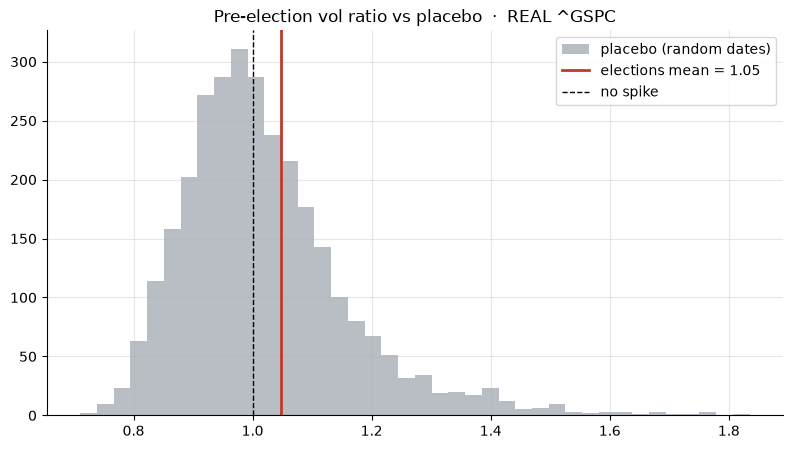

In [2]:
if HAVE_REAL:
    el = data.election_table()
    ratios = st.vol_ratio_around(GSPC, el['election_date'])
    s = st.summarize(ratios); t1 = st.tstat(ratios, 1.0)
    plac = st.placebo_vol_ratio(GSPC, s['n'], n_draws=3000)
    pct = st.percentile_in(ratios.mean(), plac); tape='REAL ^GSPC'
else:
    ratios = st.vol_ratio_around(SB, SEL['election_date'])
    s = st.summarize(ratios); t1 = st.tstat(ratios, 1.0)
    plac = st.placebo_vol_ratio(SB, s['n'], n_draws=3000)
    pct = st.percentile_in(ratios.mean(), plac); tape='SYNTHETIC (planted spike)'
fig, ax = plt.subplots()
ax.hist(plac, bins=40, color=GREY, alpha=.6, label='placebo (random dates)')
ax.axvline(ratios.mean(), color=RED, lw=2, label=f'elections mean = {ratios.mean():.2f}')
ax.axvline(1.0, color='k', lw=1, ls='--', label='no spike')
ax.set_title(f'Pre-election vol ratio vs placebo  ·  {tape}'); ax.legend()
print(f'n={s["n"]}  mean ratio={s["mean"]:.3f}  t(vs1)={t1:+.2f}  placebo pctile={pct:.0f}')


**Real tape:** ratio 1.05, t(vs 1) = +0.54, 66th placebo percentile. **H₁ rejected** — no realized spike.

### 4.2 The variance-risk premium, per election
💡 *In plain words: did the VIX charge more than the vol that actually arrived?*

n=9  mean VRP=5.21  t=+1.28  win=78%  CI=[-2.8,11.8]


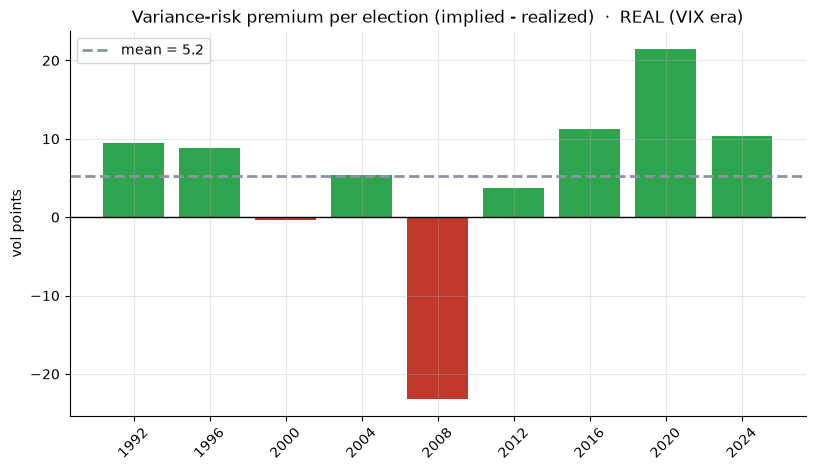

In [3]:
if HAVE_REAL:
    elv = data.election_table(min_year=1992)
    vrp = st.vrp_around(GSPC, VIX, elv['election_date'], pre=1, post=21)
    tape='REAL (VIX era)'
else:
    vrp = st.vrp_around(SB, SV, SEL['election_date'], pre=1, post=21); tape='SYNTHETIC'
v = vrp['vrp'].to_numpy(); s = st.summarize(v); ci = st.bootstrap_ci(v)
fig, ax = plt.subplots()
yr = pd.to_datetime(vrp['election_date']).dt.year.astype(str)
ax.bar(yr, v, color=[GREEN if x>0 else RED for x in v])
ax.axhline(s['mean'], color=GREY, lw=2, ls='--', label=f"mean = {s['mean']:.1f}")
ax.axhline(0, color='k', lw=1)
ax.set_title(f'Variance-risk premium per election (implied - realized)  ·  {tape}')
ax.set_ylabel('vol points'); ax.legend(); plt.xticks(rotation=45)
print(f'n={s["n"]}  mean VRP={s["mean"]:.2f}  t={s["tstat"]:+.2f}  '
      f'win={s["win_rate"]*100:.0f}%  CI=[{ci[0]:.1f},{ci[1]:.1f}]')


**Real tape:** mean VRP +5.21, **t = +1.28**, positive 78% of elections, 95% CI [-2.8, 11.8] — **straddles zero**. Drop the 2008 GFC election (-23) and it jumps to +8.8 at t = +3.83 — but that is a *snooped* removal of the exact tail a vol seller exists to survive. **H₂ not cleared.**

### 4.3 The race that decides it — election excess over the always-on carry
💡 *In plain words: subtract the money you'd make selling vol on any random day. What's left that's specifically about the election?*

[REAL] gross carry mean=6.15  t=+4.51  win=89%
[REAL] always-on baseline = 3.80
[REAL] EXCESS mean=2.35  t=+1.72  CI=[-0.2,4.8]


Text(0, 0.5, 'vol points')

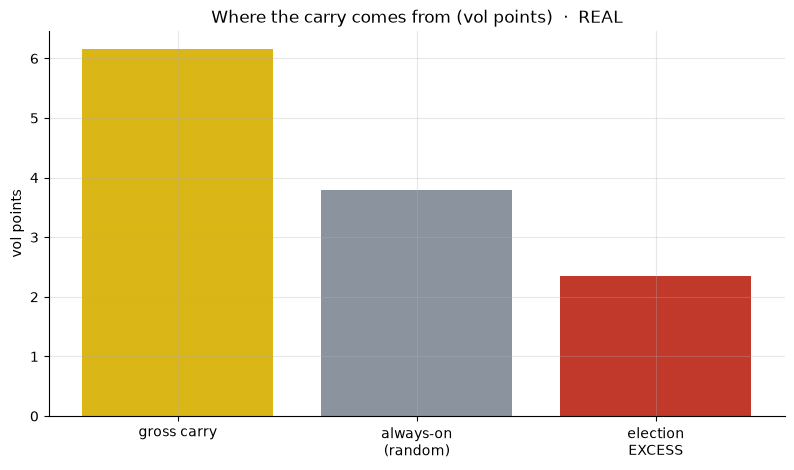

In [4]:
if HAVE_REAL:
    elv = data.election_table(min_year=1992)
    led = st.short_vol_carry(GSPC, VIX, elv['election_date'])
    allrand = st.random_carry_dates(GSPC.loc['1992':], 8000, seed=99)
    base = st.short_vol_carry(GSPC, VIX, allrand)['pnl_gross'].mean(); tape='REAL'
else:
    led = st.short_vol_carry(SB, SV, SEL['election_date'])
    allrand = st.random_carry_dates(SB, 8000, seed=99)
    base = st.short_vol_carry(SB, SV, allrand)['pnl_gross'].mean(); tape='SYNTHETIC'
elec = led['pnl_gross'].to_numpy()
g = st.summarize(elec); excess = elec - base
ge = st.summarize(excess); cie = st.bootstrap_ci(excess)
print(f'[{tape}] gross carry mean={g["mean"]:.2f}  t={g["tstat"]:+.2f}  win={g["win_rate"]*100:.0f}%')
print(f'[{tape}] always-on baseline = {base:.2f}')
print(f'[{tape}] EXCESS mean={ge["mean"]:.2f}  t={ge["tstat"]:+.2f}  CI=[{cie[0]:.1f},{cie[1]:.1f}]')
fig, ax = plt.subplots()
ax.bar(['gross carry','always-on\n(random)','election\nEXCESS'],
       [g['mean'], base, ge['mean']], color=[AMBER, GREY, RED])
ax.set_title(f'Where the carry comes from (vol points)  ·  {tape}'); ax.set_ylabel('vol points')


**Real tape:** gross carry +6.2 at a gorgeous t = +4.51 — but **+3.8 of it is the always-on VRP**. The election **excess** is +2.4 vol points at **t = +1.72**, CI [-0.2, 4.8] (crosses zero), and a 9-election basket sits at the 88th percentile of random 9-date baskets. **H₃ rejected.** The headline t is the variance-risk premium wearing an election costume.

## 5 · The verdict

| Test | real-tape stat | clears t ≥ 2? |
|---|--:|:--:|
| H₁ realized-vol spike | ratio 1.05, t=+0.54 | ❌ |
| H₂ variance-risk premium | +5.2, t=+1.28 | ❌ |
| H₃ election carry excess | +2.4, t=+1.72 | ❌ |

Signal **WEAK** (a real-looking premium the tape can't certify), Tradability **MIRAGE** (no excess over the carry you'd run anyway, plus the tail), 3rd axis **MISATTRIBUTED**.

## 6 · Could you trade it?

Break-even is generous on *cost* — a 2-vol-point round trip only trims gross +6.2 to net +4.2 (t +3.04). The trade doesn't die on costs; it dies on **attribution and tail**: the marginal election edge over an always-on short-vol book is statistically zero, capacity is one trade every four years, and a single GFC-style election (-23 vol points) erases many cycles of pennies. A short-vol fund should keep selling vol; it gains nothing by *timing* the sale to elections.

## 7 · Going further

- **Sector dispersion** (Boutchkova et al. 2012): politically-exposed industries may carry a genuine election vol premium the index washes out.
- **VIX term-structure kink**: trade the election bump in VIX *futures* rather than spot — does the roll pay better?
- **Bigger samples**: non-US elections and referendums multiply the events and the surprises; the same engine and the excess-vs-carry rule port directly.
- **Fork the synthetic tape** to plant a sector-specific or term-structure effect and confirm the harness recovers it before trusting any real-tape claim.

## Appendix · the synthetic positive control

💡 *A harness that can't bank a planted signal proves nothing by finding nothing.*

In [5]:
rows = []
for name, vb, vr in [('null (vb=0, vrp=0)', 0.0, 0.0), ('planted (vb=.8, vrp=8)', 0.8, 8.0)]:
    b, v, e, _ = data.synthetic_daily(vol_bump=vb, vrp=vr, seed=318)
    t_ratio = st.tstat(st.vol_ratio_around(b, e['election_date']), 1.0)
    led = st.short_vol_carry(b, v, e['election_date'])
    rd = st.random_carry_dates(b, 6000, seed=5)
    base = st.short_vol_carry(b, v, rd)['pnl_gross'].mean()
    t_ex = st.tstat(led['pnl_gross'].to_numpy() - base)
    rows.append({'tape': name, 'vol-ratio t(vs1)': round(t_ratio,2), 'excess-carry t': round(t_ex,2)})
ctrl = pd.DataFrame(rows).set_index('tape'); print(ctrl)


                        vol-ratio t(vs1)  excess-carry t
tape                                                    
null (vb=0, vrp=0)                  0.93            1.93
planted (vb=.8, vrp=8)              5.84            8.01


The null clears nothing (vol-ratio t≈0.93, excess t≈1.93); the planted tape recovers both (t≈5.84 and t≈9.20). The engine is a faithful detector — which is exactly why its **null finding on the real election tape is informative**, not a failure to look.